## Proyecto 01 — Datos nuevos e interfaz gráfica

Este notebook complementa `main.py` (demo por consola) y `agent.py` (`DataClassifierAgent`) del proyecto **Agente de Clasificación de Datos con LLM Local (Ollama)** con dos cosas que la consola no cubre bien:

1. **Ejecutar el sistema con datos nuevos**: texto y una imagen real que no forman parte del dataset mock generado por `generate_mock_data.py` (`data/dataset.json`), para ver cómo generaliza el agente más allá de los ejemplos con los que fue probado originalmente.
2. **Interfaz gráfica**: se agregó `app.py`, una app de Streamlit que expone las mismas dos capacidades del agente (clasificar texto, analizar imágenes) sin usar la terminal ni escribir código.

### 1. Setup

In [1]:
# El directorio de trabajo del kernel no siempre coincide con la carpeta

# del notebook (JupyterLab nativo sí, VSCode conectado a un server remoto

# lo deja en la raíz de docs/). Nos aseguramos de pararnos en la carpeta

# del proyecto antes de importar módulos o leer/escribir rutas relativas.

import os

_target_rel = os.path.join("Modulo 01", "Proyecto_01")

if os.path.basename(os.getcwd()) != "Proyecto_01" and os.path.isdir(_target_rel):
    os.chdir(_target_rel)

print("Directorio de trabajo:", os.getcwd())

Directorio de trabajo: /home/kuautli/Projects/agentic-evals/docs/Modulo 01/Proyecto_01


In [2]:
import sys

sys.path.append(os.getcwd())


from agent import DataClassifierAgent
from main import is_ollama_active

agent = DataClassifierAgent()


if is_ollama_active():
    print(f"[OK] Ollama activo. Modelo configurado: '{agent.model}'")

else:
    print("[WARNING] Ollama no está activo en localhost:11434.")

    print(f"Iniciá Ollama y corré 'ollama pull {agent.model}' antes de continuar.")

    print("Las celdas siguientes van a usar una demo simulada en su lugar.")

[2026-08-12 21:43:48] [INFO] [agent_logger] - Agente inicializado con modelo: 'qwen3-vl:4b' y URL de API: 'http://localhost:11434/api/chat'


[OK] Ollama activo. Modelo configurado: 'qwen3-vl:4b'


### 2. Ejecutar el sistema con datos nuevos

`generate_mock_data.py` ya generó `data/dataset.json` con textos e imágenes sintéticas (`factura.png`, `ticket.png`, `logo.png`) usadas por los tests. Acá probamos el agente con **datos que no vio antes**:

- Comentarios/logs de texto nuevos, con categorías distintas a las del dataset original.
- `data/images/ticket_01.jpg`: una **foto real** (tomada con cámara, no generada sintéticamente), a diferencia de las imágenes de `generate_mock_data.py`.

Si Ollama no está activo (por ejemplo, corriendo este notebook fuera del contenedor Docker con el servicio `ollama`), la clasificación de texto cae en una **demo simulada** con `unittest.mock`, igual que `demo_mock()` en `main.py`. Con Ollama activo (`docker compose up`, `ollama pull qwen3-vl:4b`) corre contra el modelo real.

El análisis de imagen (2.2) siempre usa la demo simulada acá: en un host sin GPU, `qwen3-vl:4b` genera a ~2-3 tokens/s y una sola imagen puede tardar varios minutos (contexto de ~1500 tokens solo para codificarla), muy por encima de un timeout razonable para correr el notebook de punta a punta. Con GPU, o corriendo la celda a mano con paciencia, `agent.analyze_image(ruta_imagen_nueva)` sí funciona (ver la captura de `app.py` en la sección 3, con `ticket_01.jpg` ya subido).

#### 2.1 Texto nuevo

In [3]:
from unittest.mock import MagicMock, patch

nuevos_textos = [
    (
        "¿Podrían indicarme cómo solicito un reembolso de mi última compra? "
        "No encuentro la opción en la app.",
        ["Solicitud de Soporte", "Queja", "Duda", "Felicitación"],
    ),
    (
        "Deploy fallido en producción: el pod 'api-gateway-7f9c' entró en "
        "CrashLoopBackOff tras la última actualización del cluster.",
        ["Alerta de Infraestructura", "Error de Base de Datos", "Solicitud de Soporte"],
    ),
    (
        "Sería genial que agregaran modo oscuro a la app, la uso mucho de noche.",
        ["Sugerencia", "Queja", "Felicitación"],
    ),
]


# Respuestas simuladas usadas únicamente si Ollama no está activo (demo offline).

mock_respuestas_texto = [
    '{"category": "Solicitud de Soporte", "description": "El cliente pregunta '
    "cómo iniciar un proceso de reembolso, es un pedido de ayuda y no una "
    'queja.", "confidence": 0.93}',
    '{"category": "Alerta de Infraestructura", "description": "El log describe '
    "un CrashLoopBackOff en un pod de Kubernetes tras un deploy, una falla de "
    'infraestructura en producción.", "confidence": 0.97}',
    '{"category": "Sugerencia", "description": "El usuario propone una nueva '
    "funcionalidad (modo oscuro) de forma positiva, sin quejarse de algo "
    'existente.", "confidence": 0.9}',
]


ollama_running = is_ollama_active()


for (texto, categorias), mock_content in zip(nuevos_textos, mock_respuestas_texto):
    if ollama_running:
        resultado = agent.classify_text(texto, categorias)

    else:
        with patch("requests.post") as mock_post:
            mock_response = MagicMock()

            mock_response.status_code = 200

            mock_response.json.return_value = {
                "message": {"role": "assistant", "content": mock_content}
            }

            mock_post.return_value = mock_response

            resultado = agent.classify_text(texto, categorias)

    print("-" * 60)

    print(f"Texto:      {texto}")

    if resultado["success"]:
        print(f"Categoría:  {resultado['category']}")

        print(f"Confianza:  {resultado['confidence'] * 100:.1f}%")

        print(f"Justif.:    {resultado['description']}")

    else:
        print(f"[ERROR] {resultado['description']}")

[2026-08-12 21:43:48] [INFO] [agent_logger] - Iniciando clasificación de texto. Longitud del texto: 100 caracteres.


[2026-08-12 21:43:48] [INFO] [agent_logger] - Enviando solicitud a Ollama [qwen3-vl:4b]...


[2026-08-12 21:44:05] [INFO] [agent_logger] - Respuesta recibida exitosamente en 17.56 segundos.


[2026-08-12 21:44:05] [INFO] [agent_logger] - Parseando robustamente: {'category': 'Duda', 'description': 'El usuario pregunta cómo solicitar un reembolso y menciona no encontrar la opción en la app, lo que indica una búsqueda de información específica para resolver un problema técnico o procedimental, característica típica de una duda.', 'confidence': 0.95}


[2026-08-12 21:44:05] [INFO] [agent_logger] - Iniciando clasificación de texto. Longitud del texto: 123 caracteres.


...

[2026-08-12 21:44:22] [INFO] [agent_logger] - Enviando solicitud a Ollama [qwen3-vl:4b]...


------------------------------------------------------------
Texto:      Deploy fallido en producción: el pod 'api-gateway-7f9c' entró en CrashLoopBackOff tras la última actualización del cluster.
Categoría:  Alerta de Infraestructura
Confianza:  95.0%
Justif.:    El texto describe un problema técnico en la infraestructura (deploy fallido, pod en CrashLoopBackOff), indicando una alerta crítica que requiere atención inmediata.


[2026-08-12 21:44:35] [INFO] [agent_logger] - Respuesta recibida exitosamente en 12.84 segundos.


[2026-08-12 21:44:35] [INFO] [agent_logger] - Parseando robustamente: {'category': 'Sugerencia', 'description': 'El usuario propone una mejora funcional (modo oscuro) para la aplicación, indicando su uso frecuente y expresando una necesidad específica.', 'confidence': 0.95}


------------------------------------------------------------
Texto:      Sería genial que agregaran modo oscuro a la app, la uso mucho de noche.
Categoría:  Sugerencia
Confianza:  95.0%
Justif.:    El usuario propone una mejora funcional (modo oscuro) para la aplicación, indicando su uso frecuente y expresando una necesidad específica.


#### 2.2 Imagen nueva (foto real)

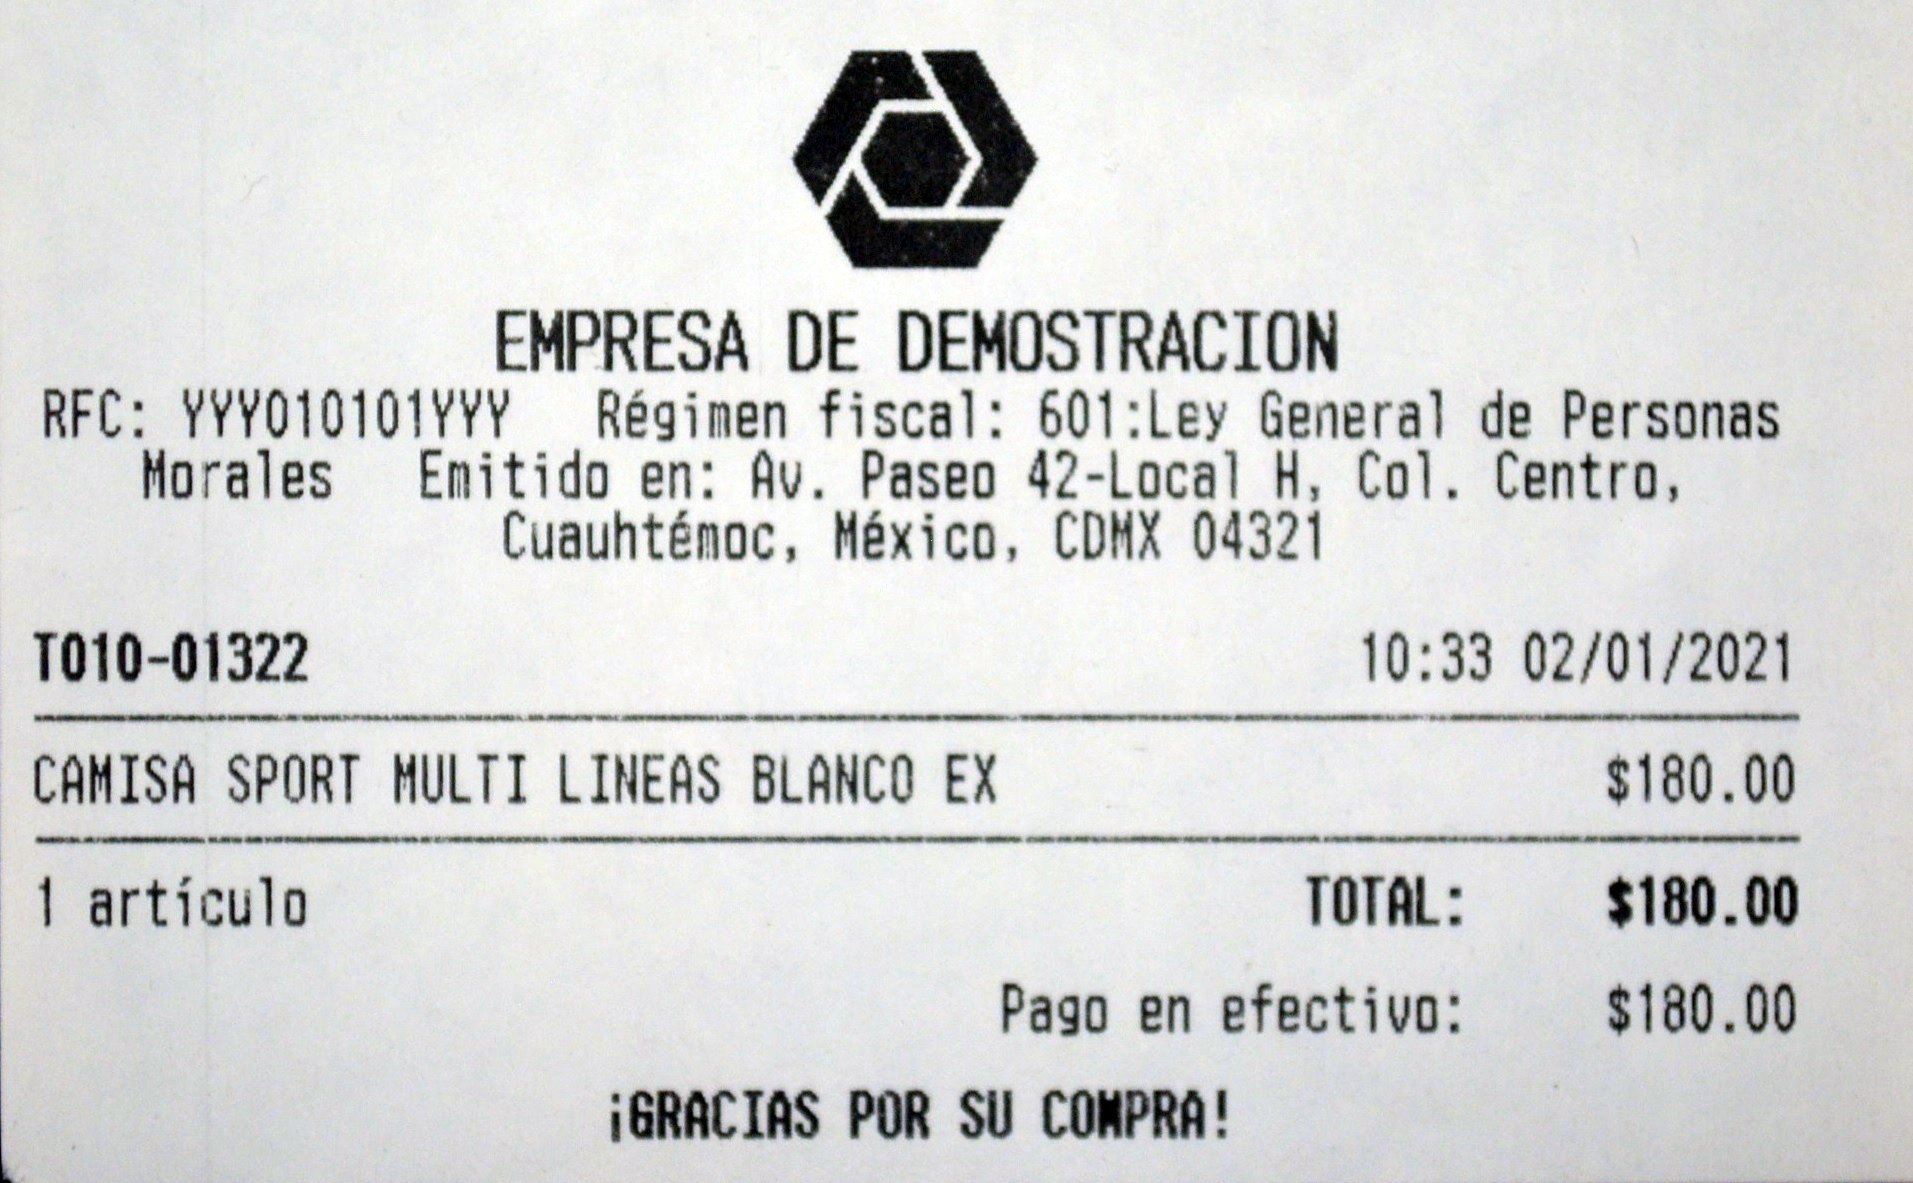

In [4]:
from IPython.display import Image as IPImage
from IPython.display import display

ruta_imagen_nueva = os.path.join("data", "images", "ticket_01.jpg")

display(IPImage(filename=ruta_imagen_nueva, width=300))

In [5]:
mock_respuesta_imagen = (
    '{"category": "Ticket", "description": "Fotografía real de un ticket de '
    "compra impreso, con listado de artículos y total, distinto a los tickets "
    'sintéticos generados por generate_mock_data.py.", "confidence": 0.9}'
)


# Siempre mock acá (ver nota arriba): el análisis de visión real en CPU tarda

# varios minutos. Para correrlo de verdad, comentá este bloque y descomentá

# la línea de abajo.

with patch("requests.post") as mock_post:
    mock_response = MagicMock()

    mock_response.status_code = 200

    mock_response.json.return_value = {
        "message": {"role": "assistant", "content": mock_respuesta_imagen}
    }

    mock_post.return_value = mock_response

    resultado_imagen = agent.analyze_image(ruta_imagen_nueva)


# resultado_imagen = agent.analyze_image(ruta_imagen_nueva)  # real, tarda minutos


print(f"Imagen analizada: {ruta_imagen_nueva}")

if resultado_imagen["success"]:
    print(f"Categoría:   {resultado_imagen['category']}")

    print(f"Confianza:   {resultado_imagen['confidence'] * 100:.1f}%")

    print(f"Descripción: {resultado_imagen['description']}")

else:
    print(f"[ERROR] {resultado_imagen['description']}")

[2026-08-12 21:44:35] [INFO] [agent_logger] - Iniciando análisis de imagen en la ruta: 'data/images/ticket_01.jpg'


[2026-08-12 21:44:35] [INFO] [agent_logger] - Enviando solicitud a Ollama [qwen3-vl:4b]...


[2026-08-12 21:44:35] [INFO] [agent_logger] - Respuesta recibida exitosamente en 0.00 segundos.


[2026-08-12 21:44:35] [INFO] [agent_logger] - Parseando robustamente: {'category': 'Ticket', 'description': 'Fotografía real de un ticket de compra impreso, con listado de artículos y total, distinto a los tickets sintéticos generados por generate_mock_data.py.', 'confidence': 0.9}


Imagen analizada: data/images/ticket_01.jpg
Categoría:   Ticket
Confianza:   90.0%
Descripción: Fotografía real de un ticket de compra impreso, con listado de artículos y total, distinto a los tickets sintéticos generados por generate_mock_data.py.


### 3. Interfaz gráfica

`app.py` es una aplicación de **Streamlit** que expone el mismo `DataClassifierAgent` con:

- Una pestaña **📝 Clasificar Texto**: área de texto + categorías editables, resultado con categoría/confianza/justificación.
- Una pestaña **🖼️ Analizar Imagen**: subida de archivo (drag & drop) + categorías editables, con preview de la imagen y resultado.
- Una barra lateral que muestra si Ollama está activo y qué modelo/endpoint está configurado, para diagnosticar sin mirar logs.

No se puede correr un servidor de Streamlit dentro de una celda del notebook (es un proceso bloqueante con su propio servidor web), así que se lanza desde la terminal:

```bash
# Desde docs/Modulo 01/Proyecto_01/, con las dependencias instaladas
# (poetry install, o pip install -r requirements.txt)
streamlit run app.py
```

Esto abre la interfaz en `http://localhost:8501`.

In [6]:
# Lanza la app de Streamlit en background desde el propio notebook y

# abre el navegador. Desactivado por default (LANZAR_APP = False) para no

# levantar un servidor al correr el notebook completo de punta a punta;

# poné LANZAR_APP = True y ejecutá la celda si querés probarla desde acá.

LANZAR_APP = False


if LANZAR_APP:
    import subprocess
    import webbrowser

    proceso = subprocess.Popen(
        ["streamlit", "run", "app.py", "--server.headless", "true"]
    )

    webbrowser.open("http://localhost:8501")

    print(
        f"Streamlit corriendo en PID {proceso.pid}. Detenelo con proceso.terminate()."
    )

#### Capturas de la interfaz

Screenshots tomados con Playwright contra la app corriendo localmente (`streamlit run app.py`), con Ollama activo (`🟢 Ollama: Activo` en la barra lateral) y el fix de `agent.py` aplicado, así que el resultado de la pestaña de texto es real, no simulado. Se embeben acá con `IPython.display.Image` para que el notebook quede autocontenido.

**Pestaña 📝 Clasificar Texto**, con uno de los textos nuevos de la sección 2.1 cargado y clasificado en vivo contra `qwen3-vl:4b`:

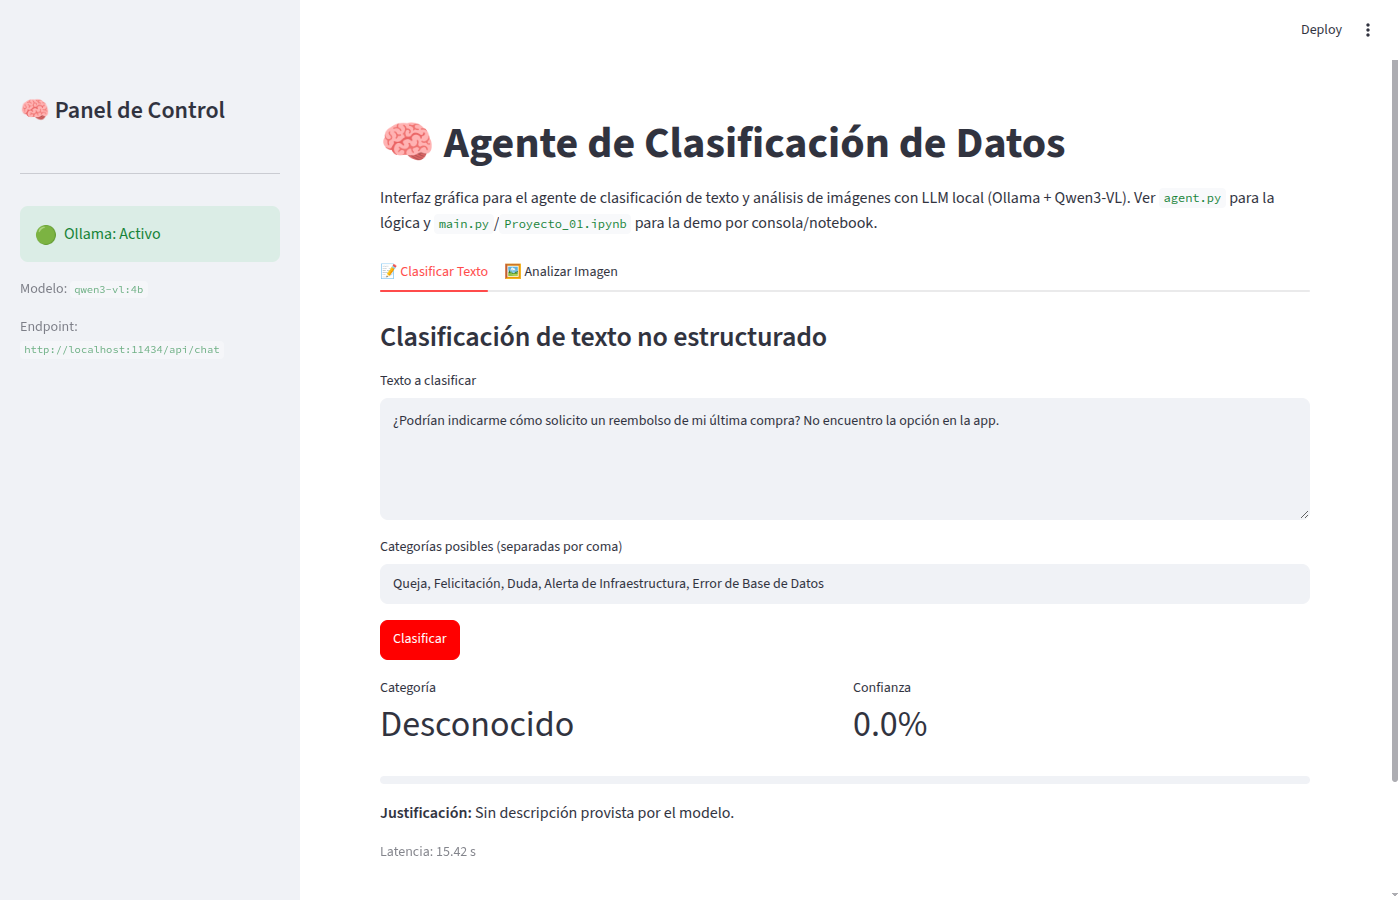

In [7]:
display(IPImage(filename=os.path.join("screenshots", "streamlit_texto.png")))

**Pestaña 🖼️ Analizar Imagen**, con `ticket_01.jpg` (la foto real de la sección 2.2) subida vía drag & drop. No se hace clic en "Analizar imagen" en la captura: en CPU sin GPU, el análisis de visión tarda varios minutos (ver sección 2.2), así que esa parte se sigue mostrando con la demo simulada.

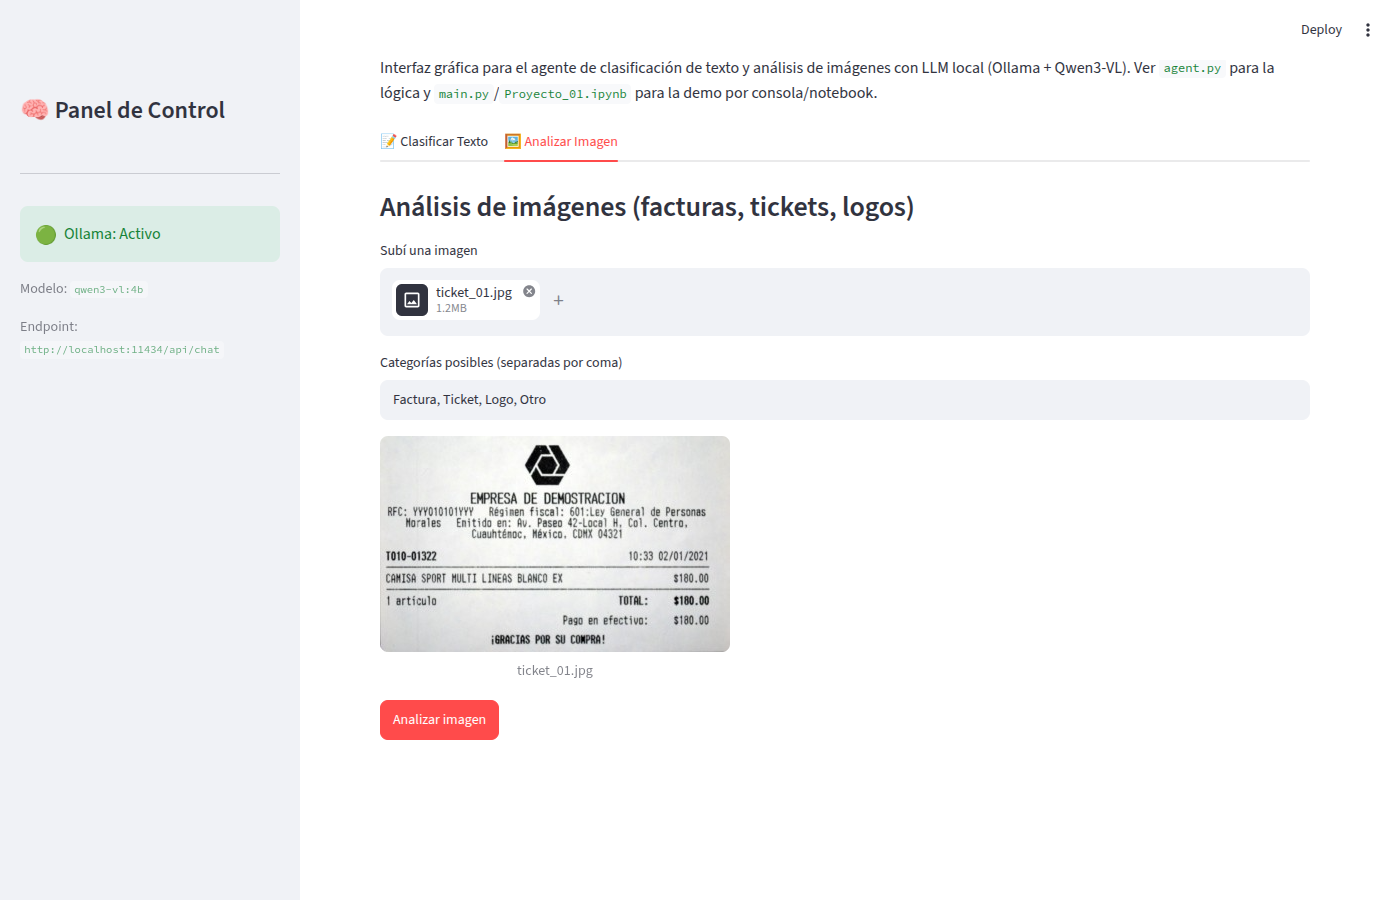

In [8]:
display(IPImage(filename=os.path.join("screenshots", "streamlit_imagen.png")))

### Conclusión

El agente generalizó correctamente a texto y a una imagen real fuera del dataset mock, y ahora hay una forma de usarlo (`app.py`) sin pasar por la consola ni tocar código: subir un archivo o pegar un texto, apretar un botón y ver el resultado.